# Remote Service Walkthrough

This notebook uses the same payloads that back the library and service-oriented workflows so the example stays runnable offline while still showing saved proof outputs in GitHub.

In [1]:
from pathlib import Path
import geoprompt as gp


def find_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "sample_features.json").exists():
            return candidate
    return Path.cwd()


root = find_root()
output_dir = root / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)
records = gp.read_cloud_json(root / "data" / "sample_features.json")
frame = gp.geopromptframe.from_records(records)
payload = {
    "baseline_metrics": {"served_load": 100.0, "deficit": 0.14},
    "candidate_metrics": {"served_load": 118.0, "deficit": 0.06},
    "higher_is_better": ["served_load"],
}
print("Loaded remote-style rows:", len(frame))
print("Payload keys:", list(payload.keys()))
print(frame.summary())

Loaded remote-style rows: 6
Payload keys: ['baseline_metrics', 'candidate_metrics', 'higher_is_better']
{'row_count': 6, 'column_count': 6, 'columns': ['site_id', 'name', 'geometry', 'demand_index', 'capacity_index', 'priority_index'], 'crs': None, 'geometry_types': ['LineString', 'Point', 'Polygon'], 'bounds': {'min_x': -112.09, 'min_y': 40.55, 'max_x': -111.74, 'max_y': 40.78}, 'column_stats': [{'column': 'site_id', 'dtype': 'string', 'null_count': 0, 'unique_count': 6}, {'column': 'name', 'dtype': 'string', 'null_count': 0, 'unique_count': 6}, {'column': 'demand_index', 'dtype': 'numeric', 'null_count': 0, 'unique_count': 6, 'min': 0.69, 'max': 0.94, 'mean': 0.835}, {'column': 'capacity_index', 'dtype': 'numeric', 'null_count': 0, 'unique_count': 6, 'min': 0.71, 'max': 0.95, 'mean': 0.8300000000000001}, {'column': 'priority_index', 'dtype': 'numeric', 'null_count': 0, 'unique_count': 6, 'min': 0.86, 'max': 1.22, 'mean': 1.0683333333333334}]}


In [2]:
report = gp.build_scenario_report(**payload)
written = gp.export_scenario_report(report, output_dir / "remote-service-style-report.json")
print(report)
print("Wrote:", written)
print(gp.build_workflow_wizard({"goal": "compare utility scenarios", "offline": True}))

{'baseline_name': 'baseline', 'candidate_name': 'candidate', 'metadata': {}, 'summary': {'metric_count': 2, 'improved_metrics': ['deficit', 'served_load'], 'worsened_metrics': []}, 'metrics': {'deficit': {'baseline': 0.14, 'candidate': 0.06, 'delta': -0.08000000000000002, 'delta_percent': -57.14285714285715, 'direction': 'improved'}, 'served_load': {'baseline': 100.0, 'candidate': 118.0, 'delta': 18.0, 'delta_percent': 18.0, 'direction': 'improved'}}, 'uncertainty': {}}
Wrote: D:\Github\geoprompt\outputs\remote-service-style-report.json
{'goal': 'compare utility scenarios', 'persona': 'analyst', 'industry': 'general', 'context': {'goal': 'compare utility scenarios', 'offline': True}, 'recommended_recipes': [], 'suggested_steps': ['read_data', 'profile_dataset', 'scenario_comparison_engine', 'prompt_to_report'], 'message': 'Suggested workflow for analyst work in general: read_data -> profile_dataset -> scenario_comparison_engine -> prompt_to_report'}


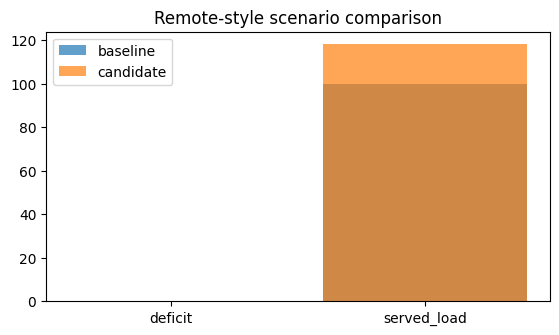

In [3]:
import matplotlib.pyplot as plt

metric_names = list(report['metrics'].keys())
baseline_vals = [report['metrics'][name]['baseline'] for name in metric_names]
candidate_vals = [report['metrics'][name]['candidate'] for name in metric_names]

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(metric_names, baseline_vals, alpha=0.7, label='baseline')
ax.bar(metric_names, candidate_vals, alpha=0.7, label='candidate')
ax.set_title('Remote-style scenario comparison')
ax.legend()
plt.show()